# COVID-19 Hospitalization Prediction

Goal: predict whether a patient is hospitalized.


# Task

Binary classification using `TIPO_PACIENTE`:

- `1`: outpatient
- `2`: hospitalized

Avoid leakage variables like ICU, intubation, and death date.


In [40]:
import pandas as pd
import numpy as np

RANDOM_STATE = 42


## 1. Load data


In [2]:
pd.set_option("display.max_columns", None)

df = pd.read_csv("data/mexico_covid19.csv", encoding="latin-1")

print("Rows, columns:", df.shape)
df.head()


Rows, columns: (263007, 41)


,id,FECHA_ARCHIVO,ID_REGISTRO,ENTIDAD_UM,ENTIDAD_RES,RESULTADO,DELAY,ENTIDAD_REGISTRO,ENTIDAD,ABR_ENT,FECHA_ACTUALIZACION,ORIGEN,SECTOR,SEXO,ENTIDAD_NAC,MUNICIPIO_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,NEUMONIA,EDAD,NACIONALIDAD,EMBARAZO,HABLA_LENGUA_INDIG,DIABETES,EPOC,ASMA,INMUSUPR,HIPERTENSION,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,MIGRANTE,PAIS_NACIONALIDAD,PAIS_ORIGEN,UCI
0,9269,2020-04-12,00011f,25,25,2,0,25,Sinaloa,SL,2020-04-19,2,12,2,25,13.0,1,2020-03-20,2020-03-12,9999-99-99,97,2,74,1,97,2,1,2,2,2,1,2,2,1,2,2,2,99,MÃÂ©xico,97,97
1,33333,2020-04-12,00014e,14,14,2,0,14,Jalisco,JC,2020-04-19,1,4,1,16,98.0,2,2020-03-30,2020-03-30,9999-99-99,2,2,71,1,2,2,1,1,2,2,1,2,2,1,2,1,99,99,MÃÂ©xico,97,2
2,35483,2020-04-12,000153,8,8,1,0,8,Chihuahua,CH,2020-04-19,1,4,2,8,19.0,2,2020-04-02,2020-03-24,9999-99-99,2,1,50,1,97,2,2,2,2,2,2,2,2,2,2,2,99,99,MÃÂ©xico,97,2
3,7062,2020-04-12,0001b6,9,15,1,0,9,Ciudad de Mexico,DF,2020-04-19,2,4,1,15,33.0,1,2020-04-01,2020-03-26,9999-99-99,97,2,25,1,2,2,2,2,2,2,2,2,2,1,2,2,99,99,MÃÂ©xico,97,97
4,23745,2020-04-12,0001c1,9,9,2,0,9,Ciudad de Mexico,DF,2020-04-19,1,4,1,99,15.0,1,2020-04-07,2020-04-06,9999-99-99,97,2,28,1,2,2,2,2,2,2,2,2,2,2,2,2,99,99,MÃÂ©xico,97,97


## 2. Column meanings

English meanings for all original columns, in the same order as the dataset.


In [3]:
data_dictionary = pd.DataFrame([
    ("id", "row id / index", "not a real patient feature"),
    ("FECHA_ARCHIVO", "file date", "date"),
    ("ID_REGISTRO", "case record id", "identifier"),
    ("ENTIDAD_UM", "state of medical unit", "location"),
    ("ENTIDAD_RES", "state of residence", "location"),
    ("RESULTADO", "COVID test result", "test information"),
    ("DELAY", "reporting delay", "administrative"),
    ("ENTIDAD_REGISTRO", "state where case was registered", "location"),
    ("ENTIDAD", "state name", "location"),
    ("ABR_ENT", "state abbreviation", "location"),
    ("FECHA_ACTUALIZACION", "data update date", "date"),
    ("ORIGEN", "reporting origin", "administrative"),
    ("SECTOR", "healthcare sector", "administrative"),
    ("SEXO", "sex", "demographic"),
    ("ENTIDAD_NAC", "state of birth", "demographic/location"),
    ("MUNICIPIO_RES", "municipality of residence", "location"),
    ("TIPO_PACIENTE", "patient type: outpatient or hospitalized", "target"),
    ("FECHA_INGRESO", "admission / medical visit date", "date"),
    ("FECHA_SINTOMAS", "symptom onset date", "date"),
    ("FECHA_DEF", "death date", "leakage"),
    ("INTUBADO", "intubated", "leakage"),
    ("NEUMONIA", "pneumonia", "possible leakage"),
    ("EDAD", "age", "demographic"),
    ("NACIONALIDAD", "nationality: Mexican or foreign", "demographic"),
    ("EMBARAZO", "pregnancy", "clinical"),
    ("HABLA_LENGUA_INDIG", "speaks an Indigenous language", "demographic"),
    ("DIABETES", "diabetes", "comorbidity"),
    ("EPOC", "COPD", "comorbidity"),
    ("ASMA", "asthma", "comorbidity"),
    ("INMUSUPR", "immunosuppressed", "comorbidity"),
    ("HIPERTENSION", "hypertension", "comorbidity"),
    ("OTRA_COM", "other comorbidity", "comorbidity"),
    ("CARDIOVASCULAR", "cardiovascular disease", "comorbidity"),
    ("OBESIDAD", "obesity", "comorbidity"),
    ("RENAL_CRONICA", "chronic kidney disease", "comorbidity"),
    ("TABAQUISMO", "smoking", "risk factor"),
    ("OTRO_CASO", "contact with another COVID case", "exposure"),
    ("MIGRANTE", "migrant", "demographic"),
    ("PAIS_NACIONALIDAD", "country of nationality", "demographic"),
    ("PAIS_ORIGEN", "country of origin", "demographic"),
    ("UCI", "ICU admission", "leakage"),
], columns=["column", "meaning", "note"])

data_dictionary


,column,meaning,note
0,id,row id / index,not a real patient feature
1,FECHA_ARCHIVO,file date,date
2,ID_REGISTRO,case record id,identifier
3,ENTIDAD_UM,state of medical unit,location
4,ENTIDAD_RES,state of residence,location
5,RESULTADO,COVID test result,test information
6,DELAY,reporting delay,administrative
7,ENTIDAD_REGISTRO,state where case was registered,location
8,ENTIDAD,state name,location
9,ABR_ENT,state abbreviation,location


For many binary medical columns, `1` usually means yes, `2` means no, and values like `97`, `98`, `99` mean not applicable or unknown.


## 3. Target


Binary classification. The original target column is `TIPO_PACIENTE`:

- `1`: outpatient
- `2`: hospitalized

We convert it into `hospitalized`:

- `0`: outpatient
- `1`: hospitalized

In [4]:
df["hospitalized"] = (df["TIPO_PACIENTE"] == 2).astype(int)

class_counts = df["hospitalized"].value_counts().rename(index={0: "not hospitalized", 1: "hospitalized"})
class_percentages = df["hospitalized"].value_counts(normalize=True).rename(index={0: "not hospitalized", 1: "hospitalized"}) * 100

pd.DataFrame({
    "count": class_counts,
    "percentage": class_percentages.round(2)
})


,count,percentage
hospitalized,,
not hospitalized,200838,76.36
hospitalized,62169,23.64


The target is imbalanced, so accuracy alone will not be enough.

## 4. Initial feature set

We start with demographic and comorbidity(基础病) variables. `NEUMONIA` is kept separate because it may cause leakage.

In [5]:
base_features = [
    "SEXO",
    "EDAD",
    "DIABETES",
    "EPOC",
    "ASMA",
    "INMUSUPR",
    "HIPERTENSION",
    "OTRA_COM",
    "CARDIOVASCULAR",
    "OBESIDAD",
    "RENAL_CRONICA",
    "TABAQUISMO",
    "OTRO_CASO"
]

suspicious_features = [
    "NEUMONIA"
]

target = "hospitalized"

In [6]:
feature_summary = []

for col in base_features + suspicious_features:
    counts = df[col].value_counts(dropna=False).sort_index()
    feature_summary.append({
        "feature": col,
        "unique_values": list(counts.index),
        "n_unique": df[col].nunique(dropna=False),
        "missing_or_unknown_count": df[col].isin([97, 98, 99]).sum()
    })

pd.DataFrame(feature_summary)

,feature,unique_values,n_unique,missing_or_unknown_count
0,SEXO,"[1, 2]",2,0
1,EDAD,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",117,121
2,DIABETES,"[1, 2, 98]",3,1011
3,EPOC,"[1, 2, 98]",3,931
4,ASMA,"[1, 2, 98]",3,923
5,INMUSUPR,"[1, 2, 98]",3,1038
6,HIPERTENSION,"[1, 2, 98]",3,938
7,OTRA_COM,"[1, 2, 98]",3,1344
8,CARDIOVASCULAR,"[1, 2, 98]",3,961
9,OBESIDAD,"[1, 2, 98]",3,962


## 5. Prepare selected features

We create a smaller dataset with the selected features and the target. Unavailable values such as `98` and `99` are treated as missing.

In [7]:
# Keep only the selected base features and the target
model_df = df[base_features + [target]].copy()

# Binary features exclude age because age is numeric
binary_features = [col for col in base_features if col != "EDAD"]

# Official missing / unknown codes in this dataset
unknown_codes = [97, 98, 99]

# Apply fixed recoding rules:
# for medical variables: 1 = yes, 2 = no
# for SEXO: 1 = female, 2 = male
# after recoding: 2 becomes 0, and 1 stays 1
for col in binary_features:
    model_df[col] = model_df[col].replace(unknown_codes, np.nan)
    model_df[col] = model_df[col].replace({2: 0})

# Check cleaned and encoded data
model_df.head()

,SEXO,EDAD,DIABETES,EPOC,ASMA,INMUSUPR,HIPERTENSION,OTRA_COM,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,hospitalized
0,0,74,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0
1,1,71,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,NaN,1
2,0,50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1
3,1,25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,0
4,1,28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0


After recoding, binary features use `1/0` coding. For medical variables, `1 = yes` and `0 = no`. For `SEXO`, `1 = female` and `0 = male`.

In [8]:
# Check coding after cleaning
# 1.0 = yes, 0.0 = no, NaN = missing/unknown
for col in binary_features:
    print(col)
    print(model_df[col].value_counts(dropna=False).sort_index())
    print()

SEXO
SEXO
0    134313
1    128694
Name: count, dtype: int64

DIABETES
DIABETES
0.0    227986
1.0     34010
NaN      1011
Name: count, dtype: int64

EPOC
EPOC
0.0    256889
1.0      5187
NaN       931
Name: count, dtype: int64

ASMA
ASMA
0.0    252565
1.0      9519
NaN       923
Name: count, dtype: int64

INMUSUPR
INMUSUPR
0.0    256916
1.0      5053
NaN      1038
Name: count, dtype: int64

HIPERTENSION
HIPERTENSION
0.0    217833
1.0     44236
NaN       938
Name: count, dtype: int64

OTRA_COM
OTRA_COM
0.0    252034
1.0      9629
NaN      1344
Name: count, dtype: int64

CARDIOVASCULAR
CARDIOVASCULAR
0.0    255262
1.0      6784
NaN       961
Name: count, dtype: int64

OBESIDAD
OBESIDAD
0.0    218287
1.0     43758
NaN       962
Name: count, dtype: int64

RENAL_CRONICA
RENAL_CRONICA
0.0    256341
1.0      5729
NaN       937
Name: count, dtype: int64

TABAQUISMO
TABAQUISMO
0.0    238296
1.0     23729
NaN       982
Name: count, dtype: int64

OTRO_CASO
OTRO_CASO
0.0    82677
1.0    97216
NaN  

## *Leakage audit

The prediction moment is assumed to be the initial clinical evaluation.
Before modeling, we check important or potentially problematic variables.

In [9]:
# Create a small table to record whether important variables are safe to use
leakage_audit = pd.DataFrame([
    {
        "variable": "EDAD",
        "meaning": "age",
        "available_at_prediction_time": "yes",
        "included": "yes",
        "reason": "Baseline demographic information."
    },
    {
        "variable": "SEXO",
        "meaning": "sex",
        "available_at_prediction_time": "yes",
        "included": "yes",
        "reason": "Baseline demographic information."
    },
    {
        "variable": "Comorbidities",
        "meaning": "diabetes, asthma, hypertension, epoc etc.",
        "available_at_prediction_time": "yes",
        "included": "yes",
        "reason": "Usually known from patient history."
    },
    {
        "variable": "OTRO_CASO",
        "meaning": "contact with another COVID case",
        "available_at_prediction_time": "probably yes",
        "included": "yes",
        "reason": "Exposure history may be asked during initial evaluation, but it has many unknown values."
    },
    {
        "variable": "NEUMONIA",
        "meaning": "pneumonia",
        "available_at_prediction_time": "unclear",
        "included": "no for base model",
        "reason": "Could reflect disease severity or information recorded after evaluation, so it may cause leakage."
    },
    {
        "variable": "INTUBADO",
        "meaning": "intubated",
        "available_at_prediction_time": "no",
        "included": "no",
        "reason": "This is downstream of severe hospitalization."
    },
    {
        "variable": "UCI",
        "meaning": "ICU admission",
        "available_at_prediction_time": "no",
        "included": "no",
        "reason": "This is an outcome after admission."
    },
    {
        "variable": "FECHA_DEF",
        "meaning": "death date",
        "available_at_prediction_time": "no",
        "included": "no",
        "reason": "This is only known after the outcome."
    }
])

leakage_audit

,variable,meaning,available_at_prediction_time,included,reason
0,EDAD,age,yes,yes,Baseline demographic information.
1,SEXO,sex,yes,yes,Baseline demographic information.
2,Comorbidities,"diabetes, asthma, hypertension, epoc etc.",yes,yes,Usually known from patient history.
3,OTRO_CASO,contact with another COVID case,probably yes,yes,Exposure history may be asked during initial e...
4,NEUMONIA,pneumonia,unclear,no for base model,Could reflect disease severity or information ...
5,INTUBADO,intubated,no,no,This is downstream of severe hospitalization.
6,UCI,ICU admission,no,no,This is an outcome after admission.
7,FECHA_DEF,death date,no,no,This is only known after the outcome.


## *EDA plots

- Target distribution: shows class imbalance.
- Hospitalization rate by age group
- Hospitalization rate by comorbidity: checks which health conditions are associated with hospitalization.
- Missing values in selected features

In [10]:

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

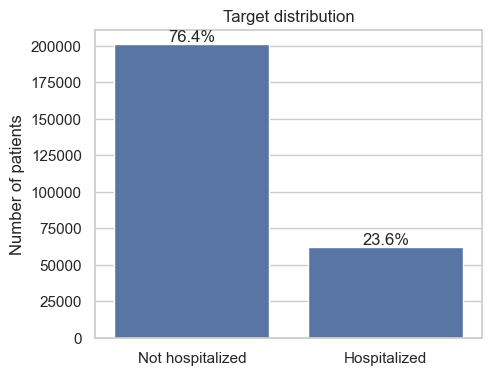

In [11]:
# Plot the number of hospitalized vs not hospitalized patients
# Count target classes and calculate percentages
target_counts = model_df[target].value_counts().sort_index()
target_percentages = model_df[target].value_counts(normalize=True).sort_index() * 100

# Plot target distribution as a bar chart
plt.figure(figsize=(5, 4))
ax = sns.barplot(
    x=target_counts.index.map({0: "Not hospitalized", 1: "Hospitalized"}),
    y=target_counts.values
)

# Add percentage labels on top of bars
for i, count in enumerate(target_counts.values):
    percentage = target_percentages.iloc[i]
    ax.text(
        i,
        count,
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Target distribution")
plt.ylabel("Number of patients")
plt.xlabel("")
plt.show()

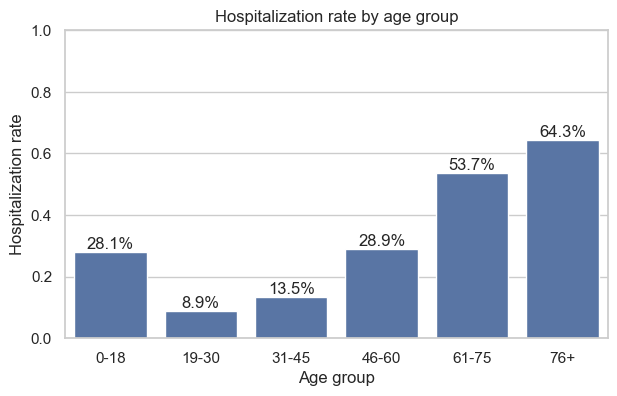

In [12]:
# Group ages into bins so the pattern is easier to see
model_df["age_group"] = pd.cut(
    model_df["EDAD"],
    bins=[0, 18, 30, 45, 60, 75, 120],
    labels=["0-18", "19-30", "31-45", "46-60", "61-75", "76+"],
    include_lowest=True
)

# Calculate hospitalization rate in each age group
age_hosp_rate = model_df.groupby("age_group", observed=True)[target].mean().reset_index()

# Plot hospitalization rate by age group
plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=age_hosp_rate,
    x="age_group",
    y=target
)

# Add percentage labels on top of bars
for i, row in age_hosp_rate.iterrows():
    ax.text(
        i,
        row[target],
        f"{row[target] * 100:.1f}%",
        ha="center",
        va="bottom"
    )

plt.title("Hospitalization rate by age group")
plt.xlabel("Age group")
plt.ylabel("Hospitalization rate")
plt.ylim(0, 1)
plt.show()

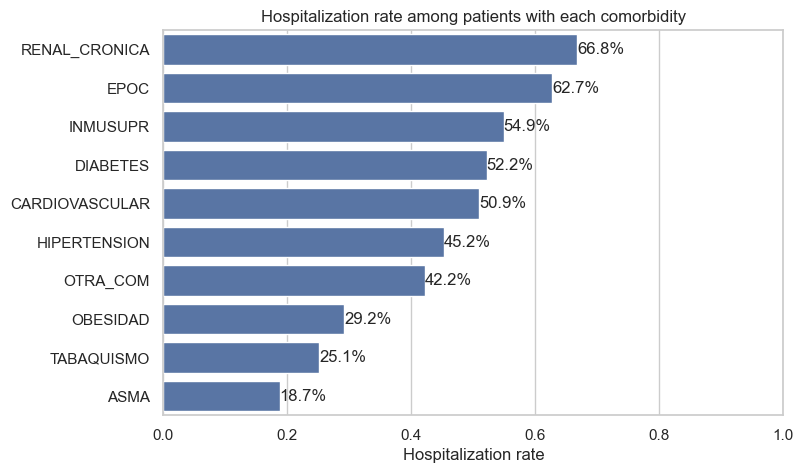

In [13]:
# Compare hospitalization rates among patients who have each comorbidity
comorbidity_features = [
    "DIABETES",
    "EPOC",
    "ASMA",
    "INMUSUPR",
    "HIPERTENSION",
    "OTRA_COM",
    "CARDIOVASCULAR",
    "OBESIDAD",
    "RENAL_CRONICA",
    "TABAQUISMO" #smoking
]

comorbidity_rates = []

for col in comorbidity_features:
    # For these columns, 1 means yes
    patients_with_condition = model_df[model_df[col] == 1]

    comorbidity_rates.append({
        "feature": col,
        "hospitalization_rate": patients_with_condition[target].mean(),
        "count": len(patients_with_condition)
    })

comorbidity_rates = pd.DataFrame(comorbidity_rates).sort_values(
    "hospitalization_rate",
    ascending=False
)

# Plot hospitalization rate by comorbidity
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=comorbidity_rates,
    y="feature",
    x="hospitalization_rate"
)

# Add percentage labels to the right of bars
for i, row in comorbidity_rates.reset_index(drop=True).iterrows():
    ax.text(
        row["hospitalization_rate"],
        i,
        f"{row['hospitalization_rate'] * 100:.1f}%",
        va="center",
        ha="left"
    )

plt.title("Hospitalization rate among patients with each comorbidity")
plt.xlabel("Hospitalization rate")
plt.ylabel("")
plt.xlim(0, 1)
plt.show()

Note: Meaning of the percentages eg. among patients with diabetes, what percentage were hospitalized?

In [14]:
# Check how many missing values each selected feature has
# This summary is used both for data inspection and for the missing-values plot
missing_summary = pd.DataFrame({
    "missing_count": model_df[base_features].isna().sum(),
    "missing_percent": (model_df[base_features].isna().mean() * 100).round(2)
})

missing_summary

,missing_count,missing_percent
SEXO,0,0.00
EDAD,0,0.00
DIABETES,1011,0.38
EPOC,931,0.35
ASMA,923,0.35
INMUSUPR,1038,0.39
HIPERTENSION,938,0.36
OTRA_COM,1344,0.51
CARDIOVASCULAR,961,0.37
OBESIDAD,962,0.37


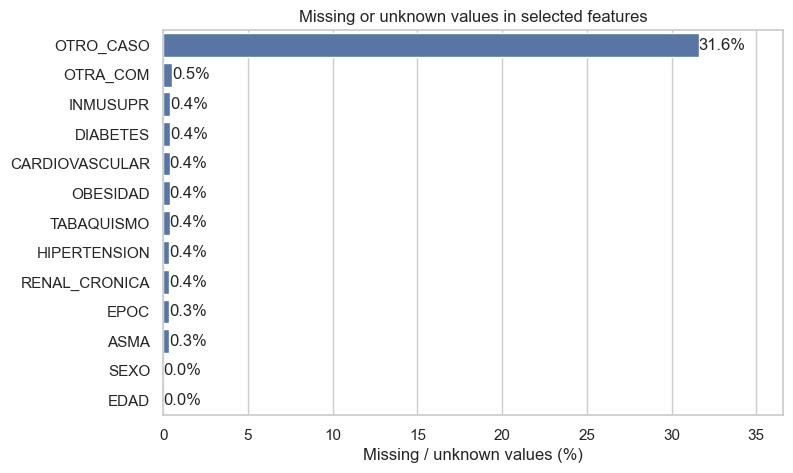

In [15]:
# Prepare missing-value data for plotting
# missing_summary was created earlier from model_df
missing_plot_data = missing_summary.reset_index().rename(columns={"index": "feature"})

# Sort features by missing percentage
missing_plot_data = missing_plot_data.sort_values("missing_percent", ascending=False)

# Plot missing/unknown percentage for each selected feature
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=missing_plot_data,
    x="missing_percent",
    y="feature"
)

# Add percentage labels next to the bars
for i, row in missing_plot_data.reset_index(drop=True).iterrows():
    ax.text(
        row["missing_percent"],
        i,
        f"{row['missing_percent']:.1f}%",
        va="center",
        ha="left"
    )

plt.title("Missing or unknown values in selected features")
plt.xlabel("Missing / unknown values (%)")
plt.ylabel("")
plt.xlim(0, max(missing_plot_data["missing_percent"]) + 5)
plt.show()

The EDA shows that the target is imbalanced: most patients were not hospitalized. 

Hospitalization rate differs across age groups: it is relatively high for the youngest group, lower for young adults, and higher again among older patients. 

some comorbidities are associated with higher hospitalization rates.

Most selected variables have few unknown values. `OTRO_CASO` has many unknown values, so we later compare models with and without this feature.

# 6. Train/test split

80/20, stratified split

The test set is kept separate and will only be used for the final evaluation.

In [16]:
from sklearn.model_selection import train_test_split

# Define X and y
# X contains only the selected input features
# y is the binary hospitalization target
X = model_df[base_features]
y = model_df[target]

# Use a stratified split so the hospitalization rate is similar in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y #split the data while preserving the target class distribution
)

# Check the sizes of the split
print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 210405
Test rows: 52602


In [17]:
# Check whether the target distribution is similar in train and test sets
split_check = pd.DataFrame({
    "full_data": y.value_counts(normalize=True).sort_index(),
    "train": y_train.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index()
})

split_check.index = ["not hospitalized", "hospitalized"]
split_check.round(3)

,full_data,train,test
not hospitalized,0.764,0.764,0.764
hospitalized,0.236,0.236,0.236


We use a stratified random split because the target is imbalanced. This keeps the hospitalization rate approximately the same in the training and test sets.

## 7. Models
We first define the model families. Training and evaluation will be done later using pipelines and cross-validation.

In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

## Baseline model

The baseline always predicts the most frequent class. It is useful as a simple reference.

In [19]:
baseline_clf = DummyClassifier(
    strategy="most_frequent"
)

baseline_clf

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


### Logistic regression

In [20]:
# max_iter gives the optimizer enough iterations to converge
# random_state makes the result reproducible
logreg_clf = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    class_weight="balanced" #updated
)

logreg_clf

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

### Random forest

Random forest can capture nonlinear relationships between variables.

In [21]:
# max_depth limits tree depth to reduce overfitting
# n_jobs=-1 uses all available CPU cores
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced" #updated

)

rf_clf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

### MLP classifier

In [22]:
mlp_clf = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=300,
    random_state=RANDOM_STATE
)

mlp_clf

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


### Model list
store the models in a dictionary so they can be compared later using the same cross-validation code.

In [23]:
models = {
    "majority baseline": baseline_clf,
    "logistic regression": logreg_clf,
    "random forest": rf_clf,
    "mlp": mlp_clf
}

models

{'majority baseline': DummyClassifier(strategy='most_frequent'),
 'logistic regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 'random forest': RandomForestClassifier(class_weight='balanced', max_depth=12, n_jobs=-1,
                        random_state=42),
 'mlp': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)}

## 8. Preprocessing pipeline

The pipeline handles missing values and scaling. These steps are learned only from the training folds during cross-validation.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Separate numeric and binary features
# EDAD is numeric; the rest are already encoded as 0/1 with possible NaN
numeric_features = ["EDAD"]
binary_features = [col for col in base_features if col != "EDAD"]

# Preprocess age:
# fill missing age with the median, then standardize it
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocess binary features:
# fill missing values with the most frequent value
binary_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

# Combine preprocessing for numeric and binary columns
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("bin", binary_transformer, binary_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## Model pipelines

We combine the preprocessing steps and each classifier into a pipeline. This ensures that imputation and scaling are learned only inside the training folds during cross-validation.

In [25]:
# Build one pipeline for each model
# Each pipeline has the same preprocessing step, followed by a different classifier
model_pipelines = {}

for model_name, clf in models.items():
    model_pipelines[model_name] = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])

model_pipelines

{'majority baseline': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['EDAD']),
                                                  ('bin',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent'))]),
                                                   ['SEXO', 'DIABETES', 'EPOC',
                                                    'ASMA', 'INMUSUPR',
                                                    'HIPERTENSION', 'OTRA_C

#### Intuition
Before running the model comparison, we expect random forest to perform well because it can capture nonlinear relationships between age and comorbidities. Logistic regression may be easier to interpret but may miss interactions. MLP is included as a different model family, but it may not necessarily work better on this tabular dataset.

## 10. Cross-validation model comparison

compare the model pipelines using stratified cross-validation on the training set only. The test set is not touched here.

In [26]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# StratifiedKFold keeps the hospitalized/not hospitalized ratio similar in each fold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Metrics:
# PR-AUC is useful for imbalanced classification
# recall is important because missing hospitalized patients is costly
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [27]:
# Run cross-validation for each model pipeline
# Only the training set is used here
cv_results = []

for model_name, pipeline in model_pipelines.items():
    print("Running:", model_name)
    
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    cv_results.append({
        "model": model_name,
        "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
        "pr_auc": scores["test_pr_auc"].mean()
    })

# Convert results into a table and sort by PR-AUC
cv_results_df = pd.DataFrame(cv_results).sort_values("pr_auc", ascending=False)

cv_results_df.round(3)

Running: majority baseline


/Users/yuqifang/miniconda3/envs/mless/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/yuqifang/miniconda3/envs/mless/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/yuqifang/miniconda3/envs/mless/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

Running: logistic regression
Running: random forest
Running: mlp


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
3,mlp,0.798,0.627,0.355,0.453,0.784,0.550
2,random forest,0.742,0.469,0.678,0.554,0.781,0.542
1,logistic regression,0.734,0.456,0.649,0.535,0.751,0.511
0,majority baseline,0.764,0.000,0.000,0.000,0.500,0.236


The CV results show that all real models outperform the majority baseline. MLP has the highest PR-AUC, while random forest has much higher recall. Since missing hospitalized patients is costly, we keep random forest as a strong candidate for the final model.

## 11. Feature ablation: OTRO_CASO

`OTRO_CASO` has many missing values, so we compare random forest performance with and without this feature. This helps decide whether to keep it in the final feature set.

In [28]:
# Create a feature set without OTRO_CASO
# This keeps all other features the same
features_without_otro_caso = [
    col for col in base_features
    if col != "OTRO_CASO"
]

# Create training data without OTRO_CASO
# Only the training set is used for this comparison
X_train_no_otro = X_train[features_without_otro_caso]

# Define feature groups for the smaller feature set
numeric_features_no_otro = ["EDAD"]
binary_features_no_otro = [
    col for col in features_without_otro_caso
    if col != "EDAD"
]

# Build a matching preprocessor without OTRO_CASO
preprocessor_no_otro = ColumnTransformer([
    ("num", numeric_transformer, numeric_features_no_otro),
    ("bin", binary_transformer, binary_features_no_otro)
])

In [29]:
# Build two random forest pipelines:
# one with OTRO_CASO and one without OTRO_CASO
rf_with_otro = model_pipelines["random forest"]

rf_without_otro = Pipeline([
    ("preprocessor", preprocessor_no_otro),
    ("classifier", rf_clf)
])

ablation_models = {
    "with OTRO_CASO": (rf_with_otro, X_train),
    "without OTRO_CASO": (rf_without_otro, X_train_no_otro)
}

In [30]:
# Compare the two pipelines using the same cross-validation setup
# The test set is still not used
ablation_results = []

for model_name, (pipeline, X_used) in ablation_models.items():
    print("Running:", model_name)
    
    scores = cross_validate(
        pipeline,
        X_used,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    
    ablation_results.append({
        "features": model_name,
        "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
        "pr_auc": scores["test_pr_auc"].mean()
    })

ablation_results_df = pd.DataFrame(ablation_results)
ablation_results_df.round(3)

Running: with OTRO_CASO
Running: without OTRO_CASO


,features,recall,f1,roc_auc,pr_auc
0,with OTRO_CASO,0.678,0.554,0.781,0.542
1,without OTRO_CASO,0.678,0.552,0.778,0.539


The ablation shows that keeping `OTRO_CASO` gives slightly better PR-AUC and F1, while recall stays the same. Although this feature has many missing values, it still adds a some useful information. We keep `OTRO_CASO` in the final feature set.

## 12. Hyperparameter search

We tune the random forest using cross-validation on the training set only. The test set is still kept untouched.

In [35]:
from sklearn.model_selection import RandomizedSearchCV

# It uses the selected feature set with OTRO_CASO
final_rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced"   #!
    ))
])

# Define hyperparameter search space
# These control model complexity and class imbalance handling
param_dist = {
    "classifier__n_estimators": [100, 150, 200],
    "classifier__max_depth": [8, 12, 16, 20],
    "classifier__min_samples_leaf": [5, 10, 20],
}

# RandomizedSearchCV tests a limited number of random combinations
# Scoring uses PR-AUC because the target is imbalanced
rf_search = RandomizedSearchCV(
    estimator=final_rf_pipeline,
    param_distributions=param_dist,
    n_iter=12,
    scoring="average_precision",  #pr-auc
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Fit the search on the training set only
rf_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [8, 12, ...], 'classifier__min_samples_leaf': [5, 10, ...], 'classifier__n_estimators': [100, 150, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",12
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be u

In [36]:
# Show the best hyperparameters and best cross-validation score
print("Best parameters:")
print(rf_search.best_params_)

print("\nBest cross-validation PR-AUC:")
print(round(rf_search.best_score_, 3))

Best parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_leaf': 20, 'classifier__max_depth': 16}

Best cross-validation PR-AUC:
0.548


In [39]:
# Display the top hyperparameter configurations
search_results = pd.DataFrame(rf_search.cv_results_)

# mean_test_score: average PR-AUC across folds
# std_test_score: std of PR-AUC across folds
search_results = search_results[
    [
        "mean_test_score",
        "std_test_score",
        "param_classifier__n_estimators",
        "param_classifier__max_depth",
        "param_classifier__min_samples_leaf",
    ]
].sort_values("mean_test_score", ascending=False)

search_results.head(10).round(4)

,mean_test_score,std_test_score,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_leaf
2,0.5481,0.0049,200,16,20
6,0.5480,0.0048,100,16,10
1,0.5476,0.0045,150,12,10
10,0.5475,0.0040,100,12,5
11,0.5475,0.0050,150,20,20
0,0.5475,0.0049,200,20,20
7,0.5475,0.0044,100,12,10
4,0.5466,0.0046,150,12,20
9,0.5465,0.0046,200,12,20
5,0.5462,0.0049,150,20,10


We fixed `class_weight="balanced"` because the target is imbalanced and missing hospitalized patients is more costly than false alarms.

The hyperparameter search tested 12 random forest configurations using 5-fold cross-validation on the training set only, so it fitted 60 models in total(within the 200 limitation)

The best selected configuration was `n_estimators = 200`, `max_depth = 16`, and `min_samples_leaf = 20`, with a cross-validation PR-AUC of about 0.548. However, several top configurations had almost identical rounded PR-AUC, so the model does not appear very sensitive to these hyperparameter variatiosn.

## 13. Final test-set evaluation

After choosing the final feature set and tuning the random forest on the training data, we now evaluate the selected model once on the test set.

In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Get the best fitted pipeline from the hyperparameter search
# RandomizedSearchCV refits the best model on the full training set by default
best_model = rf_search.best_estimator_

# Predict labels on the test set
y_test_pred = best_model.predict(X_test)

# Predict probabilities for the positive class: hospitalized = 1
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate final test-set metrics
final_results = {
    "accuracy": accuracy_score(y_test, y_test_pred),
    "precision": precision_score(y_test, y_test_pred, zero_division=0),
    "recall": recall_score(y_test, y_test_pred, zero_division=0),
    "f1": f1_score(y_test, y_test_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, y_test_proba),
    "pr_auc": average_precision_score(y_test, y_test_proba)
}

pd.DataFrame([final_results]).round(3)

,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.731,0.456,0.703,0.553,0.783,0.549


In [43]:
# Confusion matrix for the final model
final_cm = confusion_matrix(y_test, y_test_pred)

pd.DataFrame(
    final_cm,
    index=["Actual not hospitalized", "Actual hospitalized"],
    columns=["Predicted not hospitalized", "Predicted hospitalized"]
)

,Predicted not hospitalized,Predicted hospitalized
Actual not hospitalized,29734,10434
Actual hospitalized,3698,8736


This is the only final evaluation on the held-out test set. I report PR-AUC because the target is imbalanced, and recall because missing hospitalized patients is costly in a triage setting.